In [4]:
import cv2
import matplotlib.pyplot as plt


#Load Haar Cascade classifiers

# Load predefined face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades
+ 'haarcascade_frontalface_default.xml')

#Load predefined eye detector
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades
+ 'haarcascade_eye.xml')

# Read image
image_path = "person.jpg"
img = cv2.imread(image_path)

# Convert to grayscale because grayscale is simpler and appropriate for this detection process.
# It mainly looks at brightness/intensity patterns.
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
# detectMultiScale() -> searches the image for objects matching the trained classifier.

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3,
minNeighbors=5)
#scaleFactor -> controls how much the image is resized during detection.
#min neighbors -> how many neighboring detections are required before OpenCV considers something a valid detection.
#Higher value:fewer false detections but potentially misses some objects
#Lower value:more detections but potentially more false positives





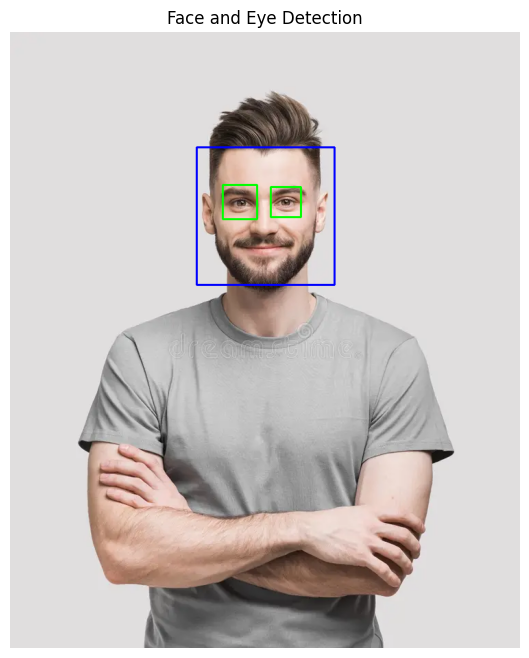

In [5]:
#Each detected face gives four values:

# x → x-coordinate
# y → y-coordinate
# w → width
# h → height

# Loop through detected faces
for (x, y, w, h) in faces:
# Draw face rectangle
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    
#(x,y) -> top-left corner
#(x+w, y+h) -> bottom-right corner
# (255,0,0) -> rectangle color 
#2 -> thickness of rectangle


#Region of Interest
# We take only the detected face region.
# Instead of searching for eyes in the entire image, we search inside the face.
    
# ROI for eyes
    roi_gray = gray[y:y + h, x:x + w] # For detecting eyes
    roi_color = img[y:y + h, x:x + w]# For displaying the color image
    
# Detect eyes from the grayscale image
    eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.3,minNeighbors=5)

# Draw bounding box in the color face region of the image
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh),(0, 255, 0), 2)


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display result
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Face and Eye Detection')
plt.show()